In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

#Hyperparameters
learning_rate = 0.0002
gamma         = 0.98

class Policy(nn.Module):
    def __init__(self):
        super(Policy, self).__init__()
        self.data = []
        
        self.fc1 = nn.Linear(4, 128)
        self.fc2 = nn.Linear(128, 2)
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.softmax(self.fc2(x), dim=0)
        return x
      
    def put_data(self, item):
        self.data.append(item)
        
    def train_net(self):
        R = 0
        self.optimizer.zero_grad()
        for r, prob in self.data[::-1]:
            R = r + gamma * R
            loss = -torch.log(prob) * R
            loss.backward()
        self.optimizer.step()
        self.data = []

def main():
    env = gym.make('CartPole-v1')
    device = "cuda" if torch.cuda.is_available() else "cpu"
    scores_total = []
    pi = Policy().to(device)
    score = 0.0
    print_interval = 20
    
    
    for n_epi in range(10000):
        s, _ = env.reset()
        done = False
        
        while not done: # CartPole-v1 forced to terminates at 500 step.
            prob = pi(torch.from_numpy(s).float().to(device))
            m = Categorical(prob)
            a = m.sample()
            s_prime, r, done, truncated, info = env.step(a.item())
            pi.put_data((r,prob[a]))
            s = s_prime
            score += r
            
        pi.train_net()
        
        if n_epi%print_interval==0 and n_epi!=0:
            print("# of episode :{}, avg score : {}".format(n_epi, score/print_interval))
            score = 0.0
    env.close()
    return scores_total, pi
    

In [3]:
scores_total, pi = main()

# of episode :20, avg score : 20.45
# of episode :40, avg score : 18.2
# of episode :60, avg score : 22.2
# of episode :80, avg score : 21.45
# of episode :100, avg score : 22.7
# of episode :120, avg score : 19.65
# of episode :140, avg score : 20.6
# of episode :160, avg score : 26.45
# of episode :180, avg score : 31.3
# of episode :200, avg score : 23.65
# of episode :220, avg score : 26.65
# of episode :240, avg score : 28.95
# of episode :260, avg score : 25.4
# of episode :280, avg score : 32.25
# of episode :300, avg score : 34.3
# of episode :320, avg score : 33.5
# of episode :340, avg score : 34.3
# of episode :360, avg score : 35.65
# of episode :380, avg score : 28.95
# of episode :400, avg score : 46.4
# of episode :420, avg score : 34.4
# of episode :440, avg score : 38.15
# of episode :460, avg score : 50.0
# of episode :480, avg score : 33.55
# of episode :500, avg score : 51.3
# of episode :520, avg score : 50.6
# of episode :540, avg score : 48.35
# of episode :560, 

In [5]:
scores_total = [20.45,18.2,22.2,21.45,22.7,19.65,20.6,26.45,31.3,23.65,26.65,28.95,25.4,32.25,34.3,33.5,34.3,35.65,28.95,46.4,34.4,38.15,50.0,33.55,51.3,50.6,48.35,45.5,62.25,43.3,54.95,58.45,55.85,77.45,65.95,95.35,70.95,81.3,79.2,66.2,66.25,90.25,100.8,117.95,98.15,100.9,92.15,110.55,167.55,113.5,113.9,133.55,126.45,112.25,176.15,162.6,179.5,145.3,135.5,183.65,197.25,180.95,236.7,208.5,197.05,193.55,212.1,193.6,148.5,180.4,200.3,169.5,234.7,225.9,216.4,227.75,217.15,213.0,257.4,251.3,209.15,257.5,253.25,228.25,304.4,261.7,240.9,271.55,269.8,283.35,253.15,281.85,240.65,305.0,299.75,294.45,262.5,310.05,305.95,250.55,304.8,275.3,276.8,358.85,335.0,309.85,369.1,395.45,318.4,389.8,304.55,295.0,304.8,310.05,417.2,364.7,334.95,412.75,482.0,314.45,328.6,330.85,352.8,292.45,260.95,351.3,390.15,381.3,440.2,338.85,390.3,491.9,705.95,518.15,464.25,501.5,538.25,577.75,606.3,540.0,519.55,524.6,612.05,555.6,653.0,728.6,526.8,486.85,471.0,841.1,626.0,626.45,767.6,729.05,505.75,504.15,596.65,815.3,591.05,868.7,815.45,709.85,447.4,574.3,499.85,566.15,694.15,923.05,976.9,1010.95,604.15,527.2,490.45,574.0,747.4,684.3,760.2,1217.9,788.2,859.9,1137.35,964.85,1048.85,905.35,962.4,1522.9,1033.45,1416.55,897.5,1058.25,990.3,1054.1,1222.5,985.85,763.85,891.35,818.5,640.45,659.05,725.45,865.05,819.0,1543.7,1341.8,1519.3,610.45,602.2,618.2,684.85,793.65,1071.55,1947.5,1933.05,1474.9,1763.35,946.5,1673.6,2754.85,2247.25,1761.4,683.9,573.05,532.5,856.65,792.7,1342.7,1884.7,2092.75,2067.7,869.1,1753.75,1840.0,2720.05,4615.3,4972.05,2910.95,6043.4,3261.45,1968.8,1616.1,996.1,1184.7,2184.9,4672.45,6294.2,6948.7,5705.1,3836.95,3130.4,2728.95,3410.15,3907.9,6366.55,8689.65,6536.75,2571.8,1609.85,1727.05,2225.9,1817.8,2403.55,3224.55,5749.1,1896.75,1528.45,985.0,1876.5,1340.25,1977.7,3047.3,4820.25,5326.75,3727.55,2516.35,1253.5,1241.5,938.6,849.5,1064.15,1972.45,2675.8,1080.0,986.2,1028.4,1012.85,815.05,872.95,951.7,1108.15,996.95,770.0,1494.3,1511.1,2132.9,1493.15,2331.05,2335.45,1944.25,1102.9,1466.95,1858.25,2312.1,2574.9,1989.05,3801.7,2331.6,2096.35,1373.3,1640.0,1816.95,1789.05,2274.75,2155.6,3043.15,1772.85,1590.3,1717.05,2639.4,2930.55,4587.05,5074.0,6009.3,7778.1,5941.8,9407.95,8132.1,10146.05,19088.65,17690.5,9792.8,14611.15,16511.4,18957.8,20945.25,6522.15,952.15,852.0,788.0,880.25,838.45,1318.65,2098.95,3152.3,1593.8,1198.45,1209.8,1008.05,971.3,1123.95,2244.2,2990.05,1631.0,1006.9,999.4,1051.95,2727.4,9383.2,13540.7,18202.15,4776.75,8606.95,15349.6,4720.3,4782.85,7907.35,12760.25,16508.8,7804.7,12523.35,25923.55,47473.25,33350.45,8820.35,18206.85,28981.45,22723.85,42787.3,28804.5,5814.25,14016.9,3895.2,1920.2,8215.25,8418.45,21759.55,22158.5,6591.15,3293.15,4011.35,3244.4,3172.95,3327.45,3488.25,3226.6,3191.6,4131.9,2797.25,3706.6,4452.45,4049.15,3643.4,2932.2,3331.3,5891.5,4800.35,5637.2,3329.55,1913.85,2429.55,3076.55,2555.6,5012.0,4377.55,5814.8,9423.0,8249.8,9376.1,8425.45,5670.5,7211.55,6127.7,4506.45,4990.95,7983.25,8262.05,7035.95,7291.55,5556.25,17398.95,13808.0,15337.9,13478.55,11899.65,16623.55,31927.4,12022.2,9069.7,5665.85,7247.95,10344.3,13919.65,11909.85,30313.3,22720.35,22590.4,13473.5,12345.8,24845.45,8918.2,15821.6,13970.65,11336.6,13802.2,17737.55,24116.3,10738.05,12930.4,16314.5,31718.25,45873.35,17180.55,41267.55,46891.45,31734.35,34419.65,23094.35,9066.15,3523.05,3594.45,4703.45,3239.05,5676.35,7262.2,5477.1,6764.7,7727.15,10172.5,18115.75,23700.2,32937.9,21055.45,49951.55,30525.9,19848.2,13691.55,27686.0,16306.9,16989.5,24469.75,9595.8,9267.55,12162.15,7806.95,1454.25,1363.35,1407.7,2771.3,9076.2,20141.9,]

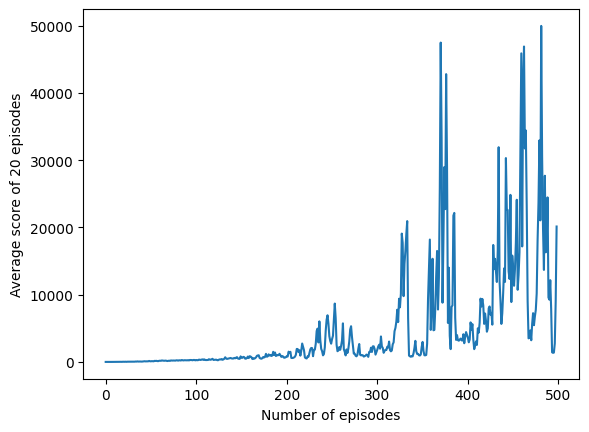

In [9]:
import matplotlib.pyplot as plt
plt.xlabel("Number of episodes")
plt.ylabel("Average score of 20 episodes")
plt.plot(scores_total)

In [11]:
torch.save(pi.state_dict(), "./pi.pt")

In [15]:
device="cuda" if torch.cuda.is_available() else "cpu"
pi = Policy().to(device)
pi.load_state_dict(torch.load("./pi.pt"))

<All keys matched successfully>